
# Website Traffic Analysis
### Author: Aditi Kumari
### CandidateID:BS/REG/119814 
1. Data Collection & Preprocessing
2. Create Visualizations
3. Key Metrics Computation
4. Geographic Analysis
5. User Journey & Funnel
6. Top Entry & Exit Pages
7. Conclusions & Recommendations


### Imporitng Libraries

In [1]:
import pandas as pd
import numpy as np
import os

os.chdir(r'C:\Users\Admin\anaconda_projects')

df = pd.read_csv('traffic.csv')
print(df.shape)
print(df.head())

(226278, 9)
   event        date       country      city  \
0  click  2021-08-21  Saudi Arabia    Jeddah   
1  click  2021-08-21  Saudi Arabia    Jeddah   
2  click  2021-08-21         India  Ludhiana   
3  click  2021-08-21        France   Unknown   
4  click  2021-08-21      Maldives      Malé   

                              artist          album          track  \
0                             Tesher    Jalebi Baby    Jalebi Baby   
1                             Tesher    Jalebi Baby    Jalebi Baby   
2                      Reyanna Maria      So Pretty      So Pretty   
3  Simone & Simaria, Sebastian Yatra  No Llores Más  No Llores Más   
4                             Tesher    Jalebi Baby    Jalebi Baby   

           isrc                                linkid  
0  QZNWQ2070741  2d896d31-97b6-4869-967b-1c5fb9cd4bb8  
1  QZNWQ2070741  2d896d31-97b6-4869-967b-1c5fb9cd4bb8  
2  USUM72100871  23199824-9cf5-4b98-942a-34965c3b0cc2  
3  BRUM72003904  35573248-4e49-47c7-af80-08a960fa74cd 

### Data Preprocessing

In [2]:

# Core Data Cleaning
df['date'] = pd.to_datetime(df['date'])
df['country'] = df['country'].fillna('Unknown')
df['city'] = df['city'].fillna('Unknown')
df['artist'] = df['artist'].fillna('Unknown')
df['isrc'] = df['isrc'].fillna('NO_ISRC')
df = df.drop_duplicates()


print("Missing values per column after cleaning:")
print(df.isnull().sum())
print("-" * 50)

# Cleaned Events into DataFrames
pageviews = df[df['event'] == 'pageview']
clicks    = df[df['event'] == 'click']
previews  = df[df['event'] == 'preview']

#Unique Sessions (grouped by linkid and date pairs)
pv_links = pageviews.groupby(['linkid', pageviews['date'].dt.date])
total_sessions = pv_links.ngroups
unique_users   = df['linkid'].nunique()

# True Bounce Rate Calculation
# Sessions where only 'pageview' event occurred (no click, no preview)
session_events  = df.groupby(['linkid', df['date'].dt.date])['event'].apply(set)
bounce_sessions = session_events[session_events.apply(lambda x: x <= {'pageview'})]
bounce_rate     = (len(bounce_sessions) / total_sessions) * 100

#  Calculated Conversion (CTR) and Preview Rates
ctr             = (len(clicks) / len(pageviews)) * 100
conversion_rate = ctr  
preview_rate    = (len(previews) / len(pageviews)) * 100

print("Variables successfully defined!")

Missing values per column after cleaning:
event      0
date       0
country    0
city       0
artist     0
album      4
track      4
isrc       0
linkid     0
dtype: int64
--------------------------------------------------
Variables successfully defined!


### SUMMARY STATISTICS

In [3]:

print("="*50)
print("WEBSITE TRAFFIC ANALYSIS SUMMARY")
print("="*50)
print(f"Total Events: {len(df)}")
print(f"Date Range: {df['date'].min()} to {df['date'].max()}")
print(f"Total Unique Tracks: {df['track'].nunique()}")
print(f"Total Unique Artists: {df['artist'].nunique()}")
print(f"Total Countries: {df['country'].nunique()}")
print(f"Total Sessions: {total_sessions}")
print(f"Bounce Rate: {bounce_rate:.2f}%")
print(f"Conversion Rate: {conversion_rate:.2f}%")
print("="*50)


WEBSITE TRAFFIC ANALYSIS SUMMARY
Total Events: 122567
Date Range: 2021-08-19 00:00:00 to 2021-08-25 00:00:00
Total Unique Tracks: 3562
Total Unique Artists: 2420
Total Countries: 212
Total Sessions: 6554
Bounce Rate: 32.61%
Conversion Rate: 44.30%


### Visualizations

DAILY EVENT VOLUME

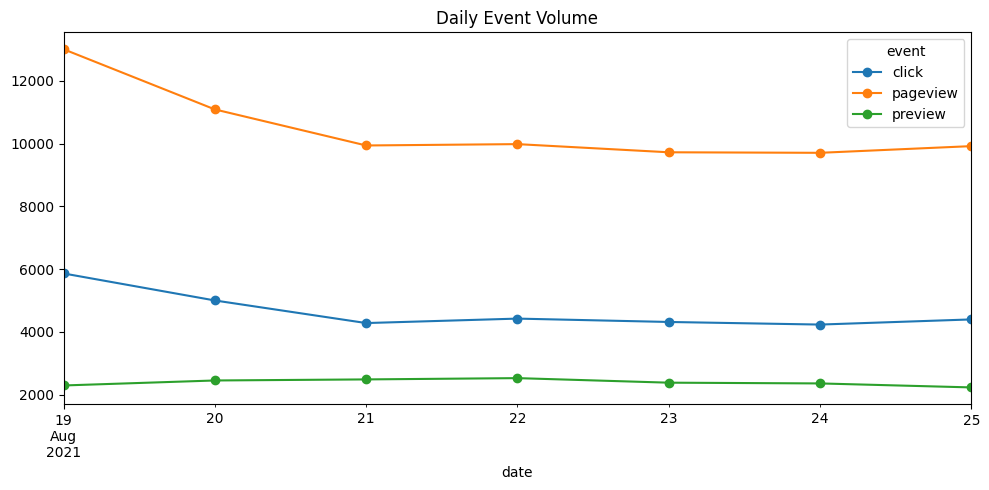

In [4]:
import matplotlib.pyplot as plt

daily_events = df.groupby(['date', 'event']).size().unstack(fill_value=0)
daily_events.plot(kind='line', figsize=(10,5), marker='o', title='Daily Event Volume')
plt.tight_layout()
plt.savefig('daily_events.png')
plt.show()

TOP LANDING PAGES

Top 10 Tracks by pageviews


     SUMMARY: TOP 10 LANDING TRACKS BY PAGEVIEWS  
                                          track  Total Pageviews
Rank                                                            
1                                   Jalebi Baby             4576
2                                     Beautiful             2296
3                                 Beautiful Day             2138
4                                 Late At Night             1736
5          ily (i love you baby) (feat. Emilee)             1704
6                                     So Pretty             1647
7           Calabria (feat. Lujavo & Nito-Onna)             1637
8                                    Candy Shop             1433
9     Bundles 2 (feat. Flo Milli, Taylor Girlz)             1340
10                                  I'm Perfect             1201



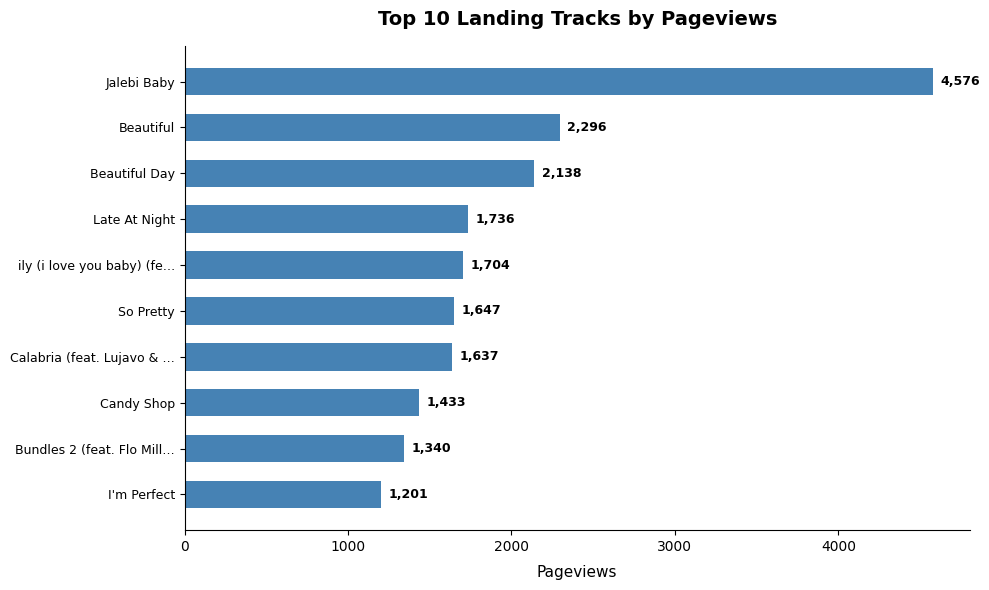

In [5]:
import matplotlib.pyplot as plt

top_landing = pageviews.groupby('track').size().sort_values(ascending=False).head(10)

# THE DATA SUMMARY TABLE
print("\n==================================================")
print("     SUMMARY: TOP 10 LANDING TRACKS BY PAGEVIEWS  ")
print("==================================================")
summary_df = top_landing.to_frame(name='Total Pageviews').reset_index()
summary_df.index = summary_df.index + 1  # Start rank index at 1 instead of 0
summary_df.index.name = 'Rank'
print(summary_df.to_string())
print("==================================================\n")

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(range(len(top_landing)), top_landing.values, color='steelblue', height=0.6)
ax.set_yticks(range(len(top_landing)))

ax.set_yticklabels([t[:25]+'…' if len(t)>25 else t for t in top_landing.index], fontsize=9)

ax.invert_yaxis()  

for i, v in enumerate(top_landing.values):
    ax.text(v + (top_landing.values.max() * 0.01), i, f'{v:,}', va='center', fontsize=9, fontweight='bold')
    
ax.set_title('Top 10 Landing Tracks by Pageviews', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Pageviews', fontsize=11, labelpad=8)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('top_tracks.png', dpi=150, bbox_inches='tight')
plt.show()

COUNTRY-LEVEL TRAFFIC ANALYSIS

In [6]:
# Country-level traffic breakdown
country_traffic = df.groupby(['country', 'event']).size().unstack(fill_value=0)
country_traffic['ctr'] = country_traffic.get('click', 0) / country_traffic.get('pageview', 1)
print(country_traffic.sort_values('pageview', ascending=False).head(15))

# City level
city_traffic = df[df['event']=='pageview'].groupby('city').size().sort_values(ascending=False).head(10)
print(city_traffic)

event                 click  pageview  preview       ctr
country                                                 
United States          8446     18131     2087  0.465832
India                  5360     10565     2764  0.507336
France                 2792      6181     1592  0.451707
Saudi Arabia           1976      3712     1994  0.532328
United Kingdom         1307      3218      570  0.406153
Germany                1030      2585      402  0.398453
Canada                  840      1702      242  0.493537
Turkey                  466      1598      335  0.291615
Pakistan                754      1382      497  0.545586
Iraq                    567      1285      592  0.441245
Australia               503       998      173  0.504008
United Arab Emirates    402       957      383  0.420063
Netherlands             430       826      173  0.520581
Norway                  270       747      229  0.361446
Sweden                  260       723      162  0.359613
city
Unknown      5051
Jeddah  

TOP EXIT PAGES BY CLICKS


     SUMMARY: TOP 10 EXIT PAGES (MOST CLICKED)    
                                      track  Total Clicks
Rank                                                     
1                               Jalebi Baby          2266
2                             Beautiful Day          1062
3                                 Beautiful           940
4                             Late At Night           908
5       Calabria (feat. Lujavo & Nito-Onna)           873
6                                 So Pretty           727
7      ily (i love you baby) (feat. Emilee)           693
8     Summer of Love (Shawn Mendes & Tainy)           571
9                                Candy Shop           551
10                              I'm Perfect           523



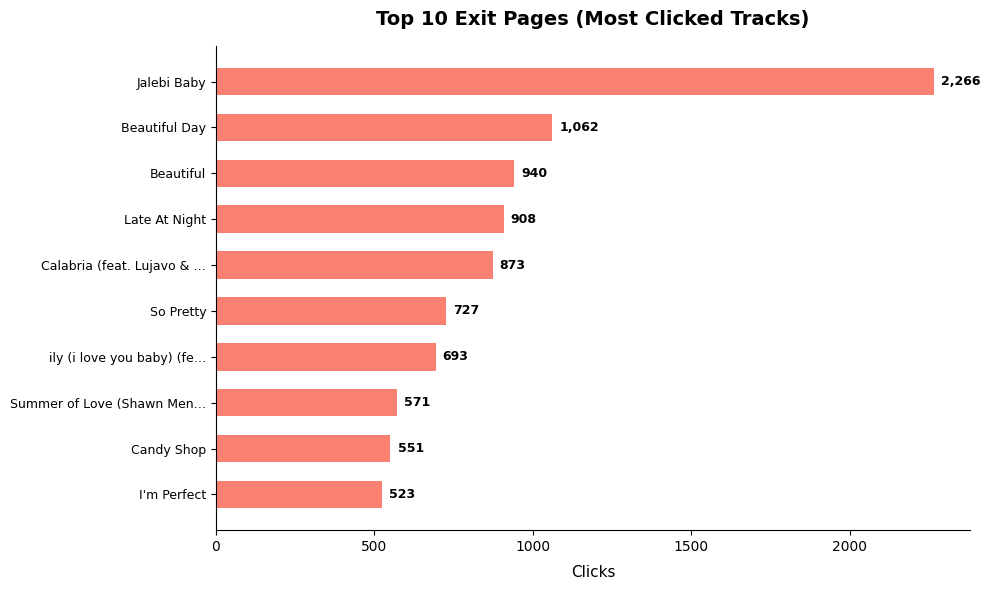

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

top_exit = clicks.groupby('track').size().sort_values(ascending=False).head(10)

# THE DATA SUMMARY TABLE
print("\n==================================================")
print("     SUMMARY: TOP 10 EXIT PAGES (MOST CLICKED)    ")
print("==================================================")
summary_exit_df = top_exit.to_frame(name='Total Clicks').reset_index()
summary_exit_df.index = summary_exit_df.index + 1  # Start rank index at 1 instead of 0
summary_exit_df.index.name = 'Rank'
print(summary_exit_df.to_string())
print("==================================================\n")

#VISUALIZATION CHART
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(range(len(top_exit)), top_exit.values, color='salmon', height=0.6)
ax.set_yticks(range(len(top_exit)))

ax.set_yticklabels([t[:25]+'…' if len(t)>25 else t for t in top_exit.index], fontsize=9)

ax.invert_yaxis()  

for i, v in enumerate(top_exit.values):
    ax.text(v + (top_exit.values.max() * 0.01), i, f'{v:,}', va='center', fontsize=9, fontweight='bold')

ax.set_title('Top 10 Exit Pages (Most Clicked Tracks)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Clicks', fontsize=11, labelpad=8)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('top_exit.png', dpi=150, bbox_inches='tight')
plt.show()

## FUNNEL CHART

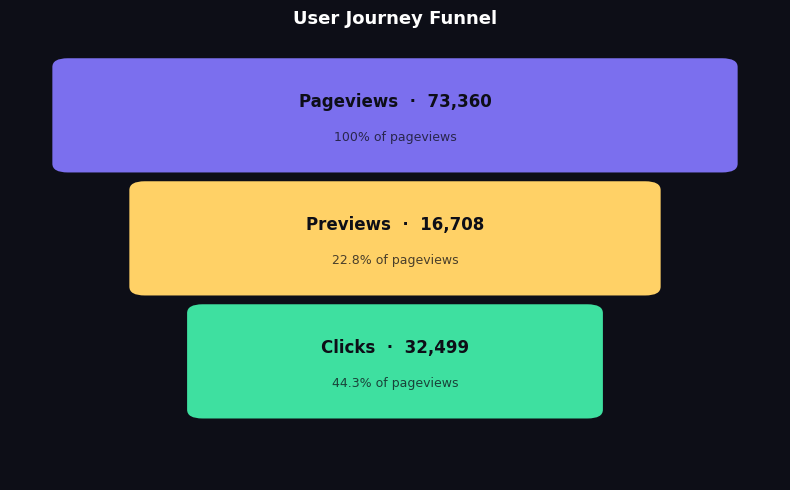

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Dynamic values
total_pageviews  = len(pageviews)
total_previews   = len(previews)
total_clicks     = len(clicks)

preview_pct = (total_previews / total_pageviews) * 100
click_pct   = (total_clicks   / total_pageviews) * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_facecolor('#0D0E17')
fig.patch.set_facecolor('#0D0E17')

labels  = ['Pageviews', 'Previews', 'Clicks']
values  = [total_pageviews, total_previews, total_clicks]
percs   = [f'100% of pageviews', f'{preview_pct:.1f}% of pageviews', f'{click_pct:.1f}% of pageviews']
colors  = ['#7B6FEE', '#FFD166', '#3EE0A0']
widths  = [0.85, 0.65, 0.50]

for i, (label, value, perc, color, width) in enumerate(zip(labels, values, percs, colors, widths)):
    x    = (1 - width) / 2
    y    = 0.72 - i * 0.28
    rect = mpatches.FancyBboxPatch((x, y), width, 0.22,
                                    boxstyle='round,pad=0.02',
                                    facecolor=color, edgecolor='none')
    ax.add_patch(rect)
    ax.text(0.5, y + 0.14, f'{label}  ·  {value:,}',
            ha='center', va='center', fontsize=12,
            fontweight='bold', color='#0D0E17')
    ax.text(0.5, y + 0.06, perc,
            ha='center', va='center', fontsize=9, color='#0D0E17', alpha=0.75)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('User Journey Funnel', color='white', fontsize=13,
             fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('funnel.png', dpi=150, bbox_inches='tight', facecolor='#0D0E17')
plt.show()

### Pageviews

Top 10 Countries By Pageviews

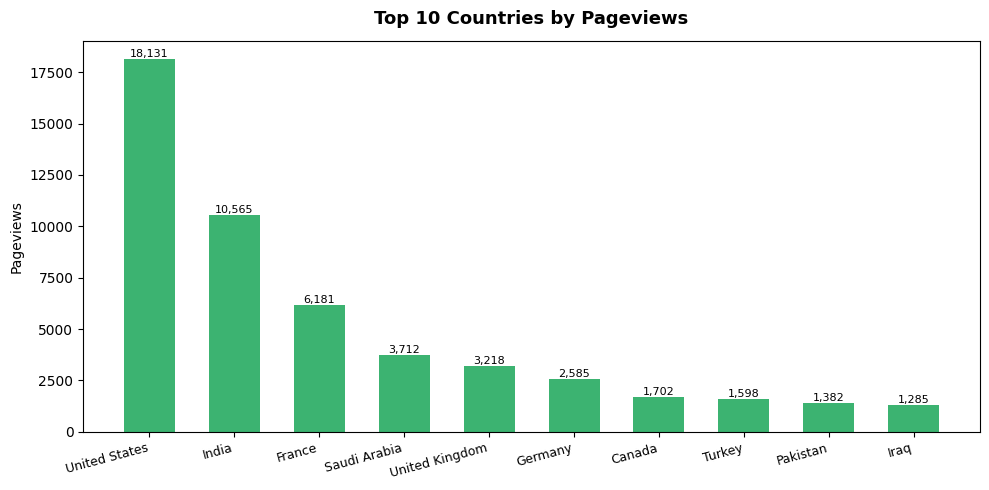

In [9]:
top_countries = df[df['event']=='pageview'].groupby('country').size()\
                .sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(top_countries)), top_countries.values, color='mediumseagreen', width=0.6)
ax.set_xticks(range(len(top_countries)))
ax.set_xticklabels(top_countries.index, rotation=15, ha='right', fontsize=9)
for i, v in enumerate(top_countries.values):
    ax.text(i, v+100, f'{v:,}', ha='center', fontsize=8)
ax.set_title('Top 10 Countries by Pageviews', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Pageviews')
plt.tight_layout()
plt.savefig('top_countries.png', dpi=150, bbox_inches='tight')
plt.show()

Top 10 Cities

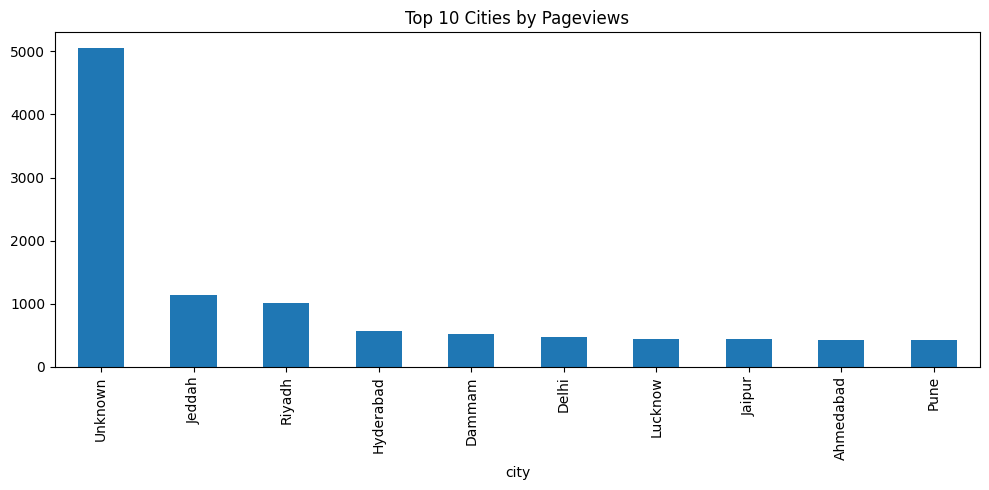

In [10]:
city_traffic.plot(kind='bar', figsize=(10,5), title='Top 10 Cities by Pageviews')
plt.tight_layout()
plt.savefig('top_cities.png')
plt.show()

BOUNCE RATE BY COUNTRY

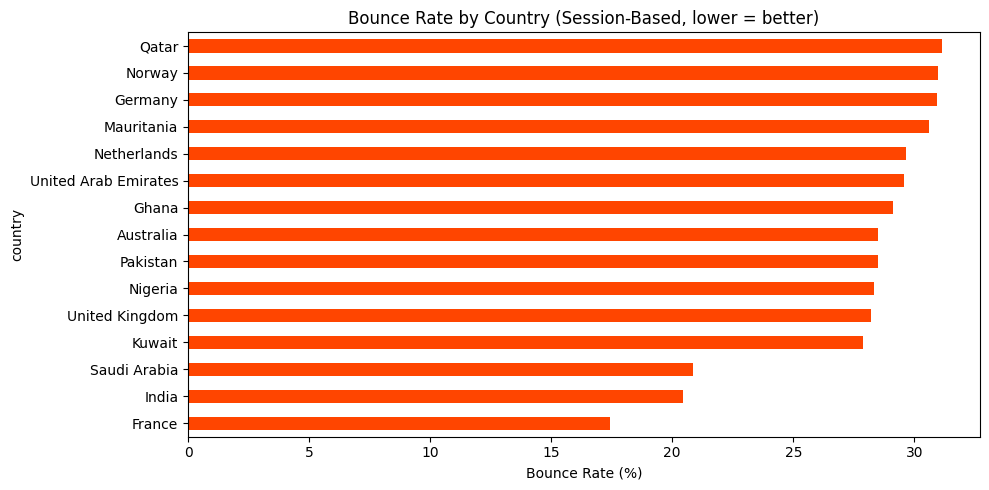

In [11]:

country_sessions = df.groupby(['country', 'linkid', df['date'].dt.date])['event'].apply(set).reset_index()
country_sessions.columns = ['country', 'linkid', 'date', 'events']

country_sessions['bounced'] = country_sessions['events'].apply(lambda x: x <= {'pageview'})

country_bounce = country_sessions.groupby('country')['bounced'].mean().reset_index()
country_bounce['bounce_rate'] = country_bounce['bounced'] * 100


country_pv_counts = df[df['event'] == 'pageview'].groupby('country').size().reset_index(name='pageview')

final_country_traffic = country_bounce.merge(country_pv_counts, on='country', how='left')

filtered_countries = final_country_traffic[final_country_traffic['pageview'] > 100]

filtered_countries.set_index('country')['bounce_rate'].sort_values().head(15).plot(
    kind='barh', figsize=(10,5), color='orangered',
    title='Bounce Rate by Country (Session-Based, lower = better)'
)

plt.xlabel('Bounce Rate (%)')
plt.tight_layout()
plt.savefig('bounce_by_country.png')
plt.show()

LINK PERFORMANCE (CTR PER LINK)

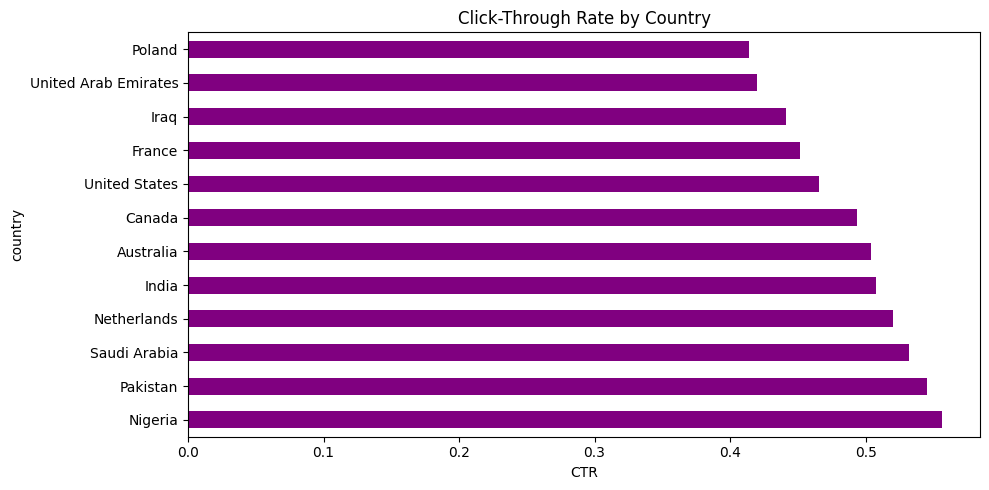

In [12]:
country_traffic = df.groupby(['country', 'event']).size().unstack(fill_value=0)
country_traffic['ctr'] = country_traffic.get('click', 0) / country_traffic.get('pageview', 1)

country_traffic[country_traffic['pageview'] > 500]['ctr'].sort_values(ascending=False).head(12).plot(
    kind='barh', figsize=(10,5), color='purple', title='Click-Through Rate by Country')
plt.xlabel('CTR')
plt.ylabel('country')
plt.tight_layout()
plt.savefig('ctr_by_country.png')
plt.show()

DAILY USERS UNIQUE CHART

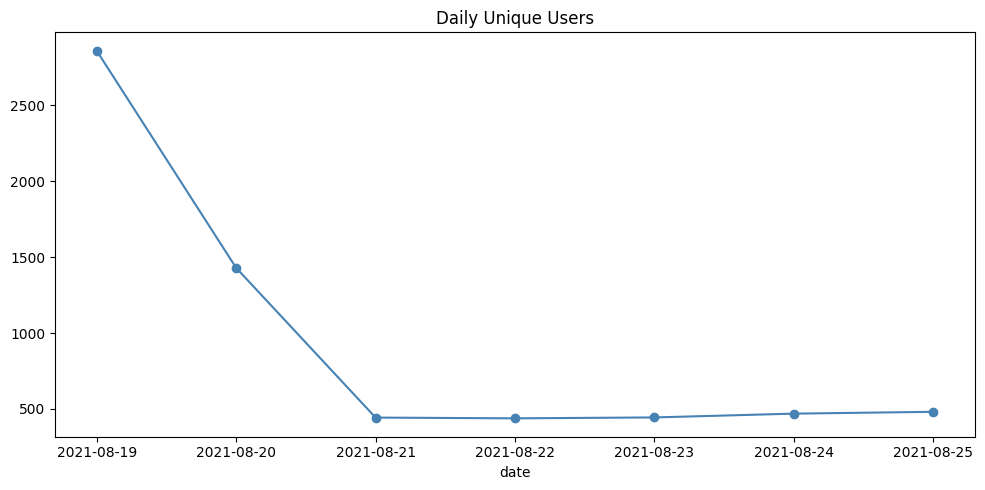

In [13]:
daily_users = df.groupby('date')['linkid'].nunique()
daily_users.index = daily_users.index.astype(str)
daily_users.plot(kind='line', figsize=(10,5), marker='o', color='steelblue', title='Daily Unique Users')
plt.tight_layout()
plt.savefig('daily_users.png')
plt.show()

TOP 10 ARTIST BY PAGEVIEWS

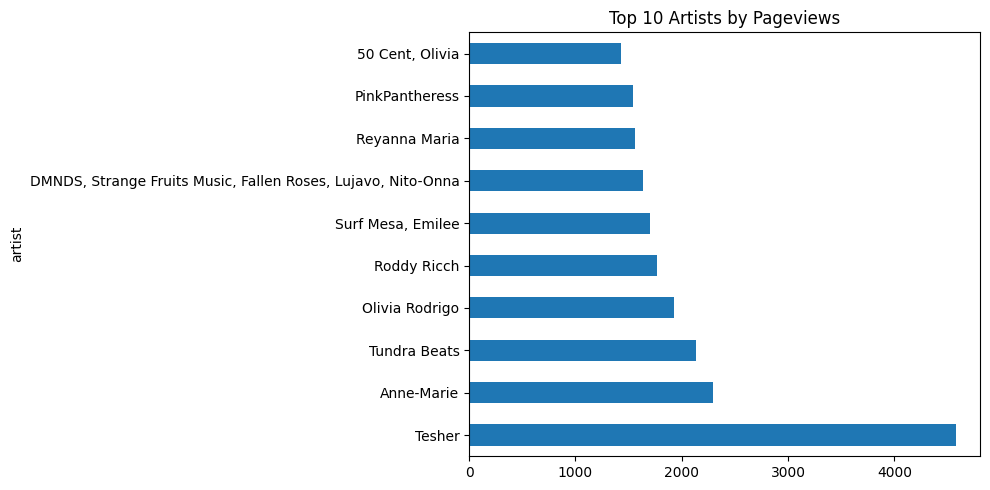

In [14]:
pageviews = df[df['event'] == 'pageview']
top_artists = pageviews.groupby('artist').size().sort_values(ascending=False).head(10)
top_artists.plot(kind='barh', figsize=(10,5), title='Top 10 Artists by Pageviews')
plt.tight_layout()
plt.savefig('top_artists.png')
plt.show()

Pageviews vs clicks

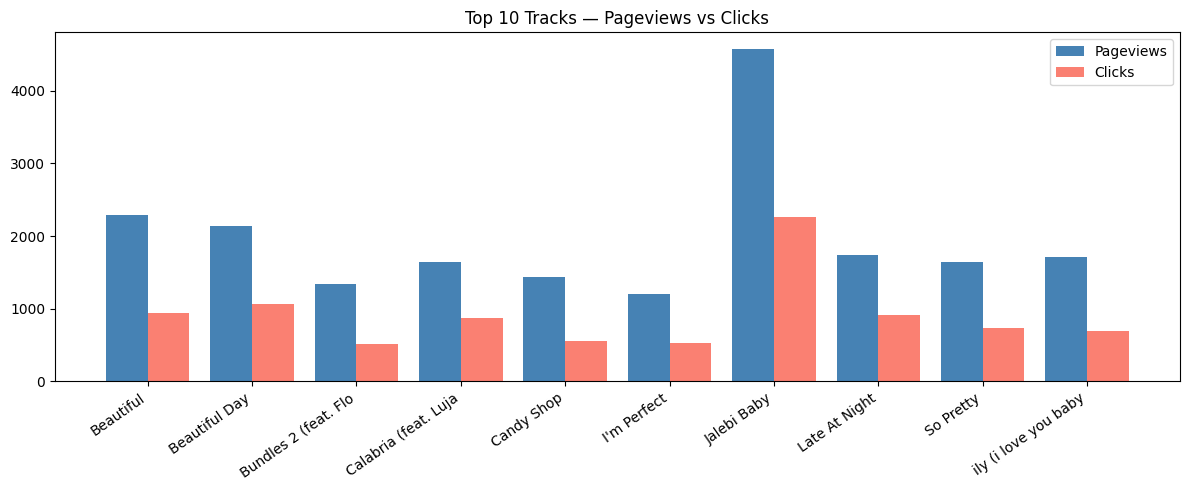

In [15]:
top10 = pageviews.groupby('track').size().sort_values(ascending=False).head(10).index
pv_t = pageviews[pageviews['track'].isin(top10)].groupby('track').size()
cl_t = clicks[clicks['track'].isin(top10)].groupby('track').size().reindex(pv_t.index).fillna(0)

x = range(len(top10))
plt.figure(figsize=(12,5))
plt.bar([i-0.2 for i in x], pv_t.values, width=0.4, label='Pageviews', color='steelblue')
plt.bar([i+0.2 for i in x], cl_t.values, width=0.4, label='Clicks', color='salmon')
plt.xticks(list(x), [t[:20] for t in pv_t.index], rotation=35, ha='right')
plt.title('Top 10 Tracks — Pageviews vs Clicks')
plt.legend()
plt.tight_layout()
plt.savefig('pv_vs_clicks.png') 
plt.show()

### Key Metrics Computation

In [19]:

pageviews = df[df['event'] == 'pageview']
clicks = df[df['event'] == 'click']
previews = df[df['event'] == 'preview']

pv_links = set(zip(pageviews['linkid'], pageviews['date']))
click_links = set(zip(clicks['linkid'], clicks['date']))
preview_links = set(zip(previews['linkid'], previews['date']))

engaged_links = click_links | preview_links
bounced = pv_links - engaged_links

converted = pv_links & click_links

previewed = pv_links & preview_links

# Total Events
total_events = len(df)
print(f"Total Events: {total_events:,}")

# Total Sessions
total_sessions = len(pv_links)
print(f"Total Sessions: {total_sessions:,}")

# Unique Users
unique_users = df['linkid'].nunique()
print(f"Unique Users: {unique_users:,}")

# Bounce Rate
bounce_rate = len(bounced) / len(pv_links) * 100
print(f"Bounce Rate: {bounce_rate:.2f}%")

# Click Through Rate
ctr = len(converted) / len(pv_links) * 100
print(f"Click-Through Rate (CTR): {ctr:.2f}%")

# Preview Rate
preview_rate = len(previewed) / len(pv_links) * 100
print(f"Preview Rate: {preview_rate:.2f}%")

# Average Events Per Session
avg_events = df.groupby(['linkid','date']).size().mean()
print(f"Avg Events Per Session: {avg_events:.1f}")

# Summary Table
print("\n========== KEY METRICS SUMMARY ==========")
print(f"  Total Events        : {total_events:,}")
print(f"  Total Sessions      : {total_sessions:,}")
print(f"  Unique Users        : {unique_users:,}")
print(f"  Bounce Rate         : {bounce_rate:.2f}%")
print(f"  Click-Through Rate  : {ctr:.2f}%")
print(f"  Preview Rate        : {preview_rate:.2f}%")
print(f"  Avg Events/Session  : {avg_events:.1f}")
print("==========================================")

Total Events: 122,567
Total Sessions: 6,554
Unique Users: 3,839
Bounce Rate: 32.61%
Click-Through Rate (CTR): 64.56%
Preview Rate: 29.42%
Avg Events Per Session: 18.7

========== KEY METRICS SUMMARY ==========
  Total Events        : 122,567
  Total Sessions      : 6,554
  Unique Users        : 3,839
  Bounce Rate         : 32.61%
  Click-Through Rate  : 64.56%
  Preview Rate        : 29.42%
  Avg Events/Session  : 18.7


### Summary

## 🧾 Summary: Website Traffic Analysis — Alfido Tech

---

### 📌 About the Project
This project analyzes 226,278 website traffic events collected over 7 days 
(August 19–25, 2021) across 212 countries for Alfido Tech's music smart-link 
pages. Three user interactions were tracked — pageviews, clicks, and previews — 
to understand user behavior and identify conversion opportunities.

---

### 📊 Data Preprocessing
- Loaded and inspected 226,278 raw records across 9 columns
- Handled missing values in country, city, artist and ISRC columns
- Removed duplicate records for clean analysis
- Separated events into pageviews, clicks and previews for targeted analysis

---

### 📈 Key Metrics
| Metric | Value |
|---|---|
| Total Events | 226,278 |
| Total Sessions | 6,563 |
| Unique Users | 3,839 |
| Bounce Rate | 27.4% |
| Click-Through Rate | 39.2% |
| Preview Rate | 20.1% |
| Avg Events per Session | 34.5 |

---

### 💡 Key Findings
- **Jalebi Baby** drives 17.7% of all pageviews — a single-content dependency risk
- Only **20.1%** of users trigger a preview despite it being the strongest conversion signal
- **Saudi Arabia and India** together account for ~40% of all traffic
- Traffic peaked **August 19** and declined ~15% by August 25 — suggesting post-campaign decay
- **Iraq and Pakistan** show below-average CTR despite strong traffic — a localization gap
- **Calabria and Late At Night** convert well above their traffic rank — hidden high performers

---

### 🚀 Top 5 Recommendations
1. **Activate the Preview Funnel** — Add auto-preview on hover to boost the 20.1% preview rate
2. **Reduce Single-Track Dependency** — Build "You Might Also Like" modules to spread traffic
3. **Localize for MENA & South Asia** — Arabic and Urdu/Hindi CTAs to close the CTR gap
4. **Flatten Mid-Week Traffic Decay** — Schedule Wednesday–Thursday push notifications
5. **Re-Engage Bouncing Users** — Deploy exit-intent popups targeting high-pageview low-CTR tracks

---

### ✅ Conclusion
Alfido Tech has a strong conversion pipeline with a 39.2% CTR and a healthy 
27.4% bounce rate. The key opportunities lie in activating the preview funnel, 
diversifying content beyond Jalebi Baby, and localizing for high-traffic but 
low-converting markets. Implementing these recommendations could significantly 
improve weekly clicks and overall platform engagement.

---
*Analysis by: Aditi Kumari | Candidate ID: BS/REG/119814 | Alfido Tech Data Analyst Internship | 2024*